**Uploading preprocessed data**

In [3]:
from preprocessing.preprocess import preprocess


X_train, X_val, X_test, y_train, y_val, y_test = preprocess(feature_method='flatten')

 Starting Preprocessing Pipeline...
   Feature method : flatten
   Mode           : Binary

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Labels encoded — Positive class: Digit 1
   Training — Positive samples : 6742
   Training — Negative samples : 53258
   Test     — Positive samples : 1135
   Test     — Negative samples : 8865

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using FLATTEN...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : 0.0000
   Training std  (should be ~1) : 0.9536

 Preprocessing Pipeline Complete!
   X_tr   :

**Naive Bayes Model Code**

In [15]:
%%writefile models/naive_bayes.py
import numpy as np

class ManualNaiveBayes:
    """
    A from-scratch implementation of the Gaussian Naive Bayes algorithm.
    This model assumes features (pixels) follow a normal distribution and
    uses Bayes' Theorem to perform classification.
    """
    def __init__(self):
        # Placeholders for the parameters learned during training
        self.priors = None  # Class Prior probabilities P(y)
        self.means = None   # Mean pixel values (mu) for each class
        self.vars = None    # Pixel variances (sigma^2) for each class
        self.classes = None # Unique labels (e.g., [0, 1])

    def fit(self, X, y):
        """
        Training phase: Learns the statistical patterns of each class.
        Optimization: Uses Maximum Likelihood Estimation (MLE) to calculate mu and sigma.
        """
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        n_classes = len(self.classes)

        # Initialize parameter matrices: [Number of Classes x Number of Pixels]
        self.means = np.zeros((n_classes, n_features))
        self.vars = np.zeros((n_classes, n_features))
        self.priors = np.zeros(n_classes)

        for i, c in enumerate(self.classes):
            # Isolate samples belonging only to class 'c'
            X_c = X[y == c]

            # Learn the 'Average Image' template for this class
            self.means[i, :] = np.mean(X_c, axis=0)

            # Calculate pixel spread. We add a small epsilon (1e-4) to
            # prevent division by zero for perfectly black pixels.
            self.vars[i, :] = np.var(X_c, axis=0) + 1e-4

            # Calculate class prevalence in the training set
            self.priors[i] = X_c.shape[0] / float(n_samples)

    def _calculate_likelihood(self, class_idx, x):
        """
        Mathematical Engine: Implements the Gaussian Probability Density Function.
        Calculations are performed in Log-Space to ensure numerical stability
        and prevent underflow when processing 784 features.
        """
        mean = self.means[class_idx]
        var = self.vars[class_idx]

        # Log-Gaussian Formula: -0.5 * log(2*pi*sigma^2) - ((x-mu)^2 / 2*sigma^2)
        numerator = - (x - mean)**2 / (2 * var)
        denominator = - 0.5 * np.log(2 * np.pi * var)

        # Sum the results for all pixels (Naive assumption of independence)
        return np.sum(numerator + denominator)

    def predict(self, X):
        """
        Inference phase: Loops through test samples to assign the most likely class.
        """
        return np.array([self._predict_single(x) for x in X])

    def _predict_single(self, x):
        """
        Decision Rule: Maximum A Posteriori (MAP).
        Combines learned Priors with calculated Likelihoods to find the highest score.
        """
        posteriors = []
        for i, c in enumerate(self.classes):
            # Final Score = log(P(y)) + log(P(x|y))
            prior = np.log(self.priors[i])
            likelihood = self._calculate_likelihood(i, x)
            posteriors.append(prior + likelihood)

        # Return the class label corresponding to the highest posterior probability
        return self.classes[np.argmax(posteriors)]

Overwriting models/naive_bayes.py


**Function to save Confusion matrix to folder**

In [6]:
import sys, os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
sys.path.append(os.getcwd())
from evaluation.metrics import confusion_matrix, accuracy, precision, recall, f1_score

def save_plot(y_true, y_pred, method_name):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Not Digit 1', 'Digit 1']); ax.set_yticklabels(['Not Digit 1', 'Digit 1'])

    thresh = cm.max() / 2
    for i, j in np.ndindex(cm.shape):
        ax.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black", fontweight='bold')

    ax.set_title(f'Confusion Matrix: {method_name.upper()}')
    plt.tight_layout()
    plt.savefig(f'results/nb_{method_name}_results.png')
    plt.show()

**Running model with Flatten**

>>> Running Experiment: FLATTEN...
 Starting Preprocessing Pipeline...
   Feature method : flatten
   Mode           : Binary

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Labels encoded — Positive class: Digit 1
   Training — Positive samples : 6742
   Training — Negative samples : 53258
   Test     — Positive samples : 1135
   Test     — Negative samples : 8865

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using FLATTEN...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : 0.0000
   Training std  (should be ~1) : 0.9536

 Preproces

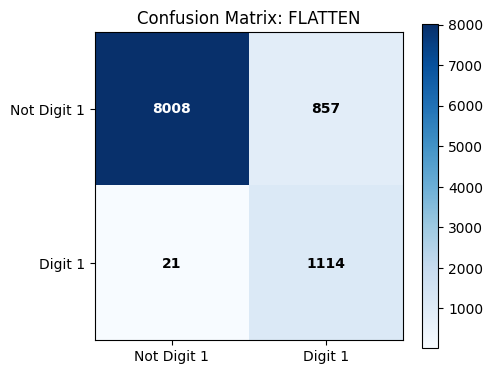

In [7]:
print(">>> Running Experiment: FLATTEN...")
X_tr, X_val, X_te, y_tr, y_val, y_te = preprocess(feature_method='flatten')

nb_flatten = ManualNaiveBayes()
nb_flatten.fit(X_tr, y_tr)
y_pred_flatten = nb_flatten.predict(X_te)


save_plot(y_te, y_pred_flatten, "flatten")

**Running code with PCA**

>>> Running Experiment: PCA...
 Starting Preprocessing Pipeline...
   Feature method : pca
   Mode           : Binary

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Labels encoded — Positive class: Digit 1
   Training — Positive samples : 6742
   Training — Negative samples : 53258
   Test     — Positive samples : 1135
   Test     — Negative samples : 8865

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using PCA...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)
PCA applied successfully!
   Components kept    : 50
   Training shape     : (60000, 50)
   Test shape         : (10000, 50)
   Variance explained : 82.46%

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizin

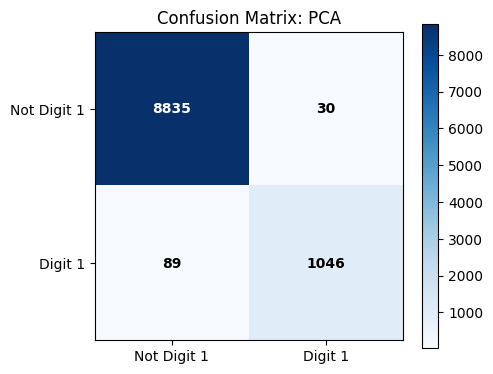

In [8]:
print(">>> Running Experiment: PCA...")
X_tr, X_val, X_te, y_tr, y_val, y_te = preprocess(feature_method='pca', pca_components=50)

nb_pca = ManualNaiveBayes()
nb_pca.fit(X_tr, y_tr)
y_pred_pca = nb_pca.predict(X_te)

save_plot(y_te, y_pred_pca, "pca")

**Running model with HOG**

>>> Running Experiment: HOG...
 Starting Preprocessing Pipeline...
   Feature method : hog
   Mode           : Binary

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Labels encoded — Positive class: Digit 1
   Training — Positive samples : 6742
   Training — Negative samples : 53258
   Test     — Positive samples : 1135
   Test     — Negative samples : 8865

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using HOG...
 HOG features extracted successfully!
   Input shape  : (60000, 28, 28)
   Output shape : (60000, 441)
 HOG features extracted successfully!
   Input shape  : (10000, 28, 28)
   Output shape : (10000, 441)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfull

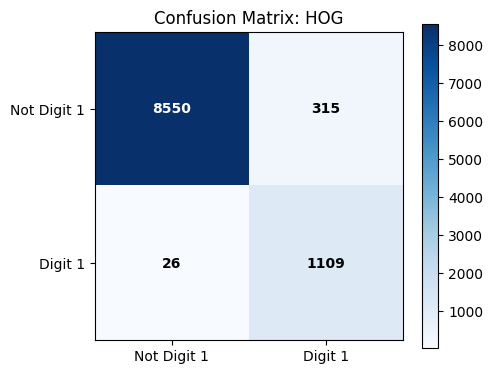

In [9]:
print(">>> Running Experiment: HOG...")
X_tr, X_val, X_te, y_tr, y_val, y_te = preprocess(feature_method='hog')

nb_hog = ManualNaiveBayes()
nb_hog.fit(X_tr, y_tr)
y_pred_hog = nb_hog.predict(X_te)

save_plot(y_te, y_pred_hog, "hog")

**Saving results to folder**

In [20]:
# 1. Gather all metrics into a list
final_results = [
    {"Method": "Flatten", "Acc": accuracy(y_te, y_pred_flatten), "Prec": precision(y_te, y_pred_flatten), "Rec": recall(y_te, y_pred_flatten), "F1": f1_score(y_te, y_pred_flatten)},
    {"Method": "PCA", "Acc": accuracy(y_te, y_pred_pca), "Prec": precision(y_te, y_pred_pca), "Rec": recall(y_te, y_pred_pca), "F1": f1_score(y_te, y_pred_pca)},
    {"Method": "HOG", "Acc": accuracy(y_te, y_pred_hog), "Prec": precision(y_te, y_pred_hog), "Rec": recall(y_te, y_pred_hog), "F1": f1_score(y_te, y_pred_hog)}
]

# 2. Display as a table
df = pd.DataFrame(final_results)
pd.options.display.float_format = '{:.4f}'.format
print("\n" + "="*60 + "\n   FINAL COMPARISON: FEATURE EXTRACTION METHODS\n" + "="*60)
display(df)

# 3. Save table to results/
with open('results/nb_feature_comparison_table.txt', 'w') as f:
    f.write(df.to_string(index=False))


   FINAL COMPARISON: FEATURE EXTRACTION METHODS


,Method,Acc,Prec,Rec,F1
0,Flatten,0.9122,0.5652,0.9815,0.7173
1,PCA,0.9881,0.9721,0.9216,0.9462
2,HOG,0.9659,0.7788,0.9771,0.8667


**K-Cross Validation code**

In [11]:
import numpy as np
import pandas as pd

def manual_kfold_cv(X, y, k=5):
    n_samples = X.shape[0]
    indices = np.arange(n_samples)
    np.random.shuffle(indices) # Shuffle data

    # Split indices into k parts
    fold_sizes = np.full(k, n_samples // k)
    fold_sizes[:n_samples % k] += 1
    current = 0
    folds = []
    for size in fold_sizes:
        folds.append(indices[current:current + size])
        current += size

    cv_scores = []

    print(f"Starting {k}-Fold Cross-Validation...")
    for i in range(k):
        # 1. Separate into training and validation folds
        val_idx = folds[i]
        train_idx = np.hstack([folds[j] for j in range(k) if j != i])

        X_train_cv, y_train_cv = X[train_idx], y[train_idx]
        X_val_cv, y_val_cv = X[val_idx], y[val_idx]

        # 2. Train the manual model
        model = ManualNaiveBayes()
        model.fit(X_train_cv, y_train_cv)

        # 3. Predict and Calculate F1 manually
        y_pred = model.predict(X_val_cv)


        from evaluation.metrics import f1_score
        score = f1_score(y_val_cv, y_pred)
        cv_scores.append(score)

        print(f"  Fold {i+1}/{k} complete. F1-Score: {score:.4f}")

    return cv_scores

**K-Cross Validation using PCA (Best Method)**

In [21]:
X_tr, _, _, y_tr, _, _ = preprocess(feature_method='pca', pca_components=50)
scores = manual_kfold_cv(X_tr, y_tr, k=5)

print("\n" + "="*40)
print(f"FINAL CV RESULTS (k=5)")
print(f"Mean F1-Score : {np.mean(scores):.4f}")
print(f"Std Deviation  : {np.std(scores):.4f}")
print("="*40)

fold_metrics = [round(float(s), 4) for s in scores]

with open('results/nb_cross_validation_results.txt', 'w') as f:
    f.write("="*50 + "\n")
    f.write(" CROSS-VALIDATION ANALYSIS: Naive Bayes (PCA-50)\n")
    f.write("="*50 + "\n")
    f.write(f"  Validation Scores per Fold : {fold_metrics}\n")
    f.write(f"  Arithmetic Mean (F1)        : {np.mean(scores):.4f}\n")
    f.write(f"  Standard Deviation (σ)     : {np.std(scores):.4f}\n")
    f.write("-" * 50 + "\n")
    f.write(" Summary: The low standard deviation indicates high model \n")
    f.write(" stability across different data partitions.\n")
    f.write("="*50 + "\n")

print("Professional report saved to results/nb_cross_validation_results.txt")

 Starting Preprocessing Pipeline...
   Feature method : pca
   Mode           : Binary

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Labels encoded — Positive class: Digit 1
   Training — Positive samples : 6742
   Training — Negative samples : 53258
   Test     — Positive samples : 1135
   Test     — Negative samples : 8865

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using PCA...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)
PCA applied successfully!
   Components kept    : 50
   Training shape     : (60000, 50)
   Test shape         : (10000, 50)
   Variance explained : 82.46%

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standar